# MURA Abnormality Detection - PyTorch Replication

Replication of the Stanford MURA baseline from Rajpurkar et al. 2018, restricted
to `XR_WRIST` and `XR_SHOULDER`.  Labels and body-part annotations are derived
directly from image paths (the `study*_positive` / `study*_negative` folder
convention), so no study manifest join is required.

### Paper contract implemented here
- DenseNet-169, ImageNet-pretrained, classifier replaced by `Linear(in, 1)`
- Weighted BCE loss with per-study-type weights
  `w_{T,1} = |N_T| / (|A_T| + |N_T|)` and `w_{T,0} = |A_T| / (|A_T| + |N_T|)`
- Resize to 320 x 320, ImageNet normalization
- Train-time augmentation: random horizontal flip + rotation up to 30 deg
- Adam (betas = 0.9, 0.999), batch size 8, initial LR 1e-4
- LR decayed by 10x on validation-loss plateau (`ReduceLROnPlateau`)
- Study-level evaluation = arithmetic mean of per-view probabilities, threshold 0.5
- Ensembling of top-5 checkpoints is intentionally skipped for efficiency

### Frozen ambiguities
- Grayscale X-rays loaded as 3-channel RGB so ImageNet weights apply
- Resize policy: simple bilinear resize to 320 x 320
- Plateau rule: `ReduceLROnPlateau(patience=1, factor=0.1)` on validation loss
- Epoch budget: 20 by default
- Labels inferred from folder names `study*_positive` / `study*_negative`


## 1. Setup

Imports, paths, hyperparameters, and device selection.  The CSV rows in MURA are
prefixed with `MURA-v1.1/...`, so `DATA_ROOT` is the workspace root (the parent
of `MURA-v1.1`).


In [1]:
import os
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import roc_auc_score, confusion_matrix, cohen_kappa_score

try:
    from tqdm.auto import tqdm
except ImportError:  # graceful fallback if tqdm is unavailable
    def tqdm(iterable=None, **kwargs):
        return iterable if iterable is not None else iter(())


In [2]:
# --- Paths -----------------------------------------------------------------
WORKSPACE_ROOT = Path('/users/idshah')
DATA_ROOT      = WORKSPACE_ROOT                        # CSV rows include 'MURA-v1.1/...'
MURA_ROOT      = WORKSPACE_ROOT / 'MURA-v1.1'
CHECKPOINT_DIR = WORKSPACE_ROOT / 'checkpoints_unweighted'
RESULTS_PATH   = WORKSPACE_ROOT / 'training_results_unweighted.json'
CHECKPOINT_DIR.mkdir(exist_ok=True)

# --- Experiment scope ------------------------------------------------------
STUDY_TYPES = ['XR_WRIST', 'XR_SHOULDER']

# --- Paper-aligned hyperparameters -----------------------------------------
IMG_SIZE     = 320
BATCH_SIZE   = 8
LR           = 1e-4
ADAM_BETAS   = (0.9, 0.999)
NUM_EPOCHS   = 20
LR_PATIENCE  = 1       # 'each time val loss plateaus after an epoch'
LR_FACTOR    = 0.1     # '10x' decay
ROTATION_DEG = 30
SEED         = 42

# --- Ensembling ------------------------------------------------------------
ENSEMBLE_SIZE = 5      # retain top-K lowest-validation-loss checkpoints

# --- Smoke-test switch -----------------------------------------------------
# True -> tiny subsample and 1 epoch for quick end-to-end verification.
SMOKE_TEST        = False
SMOKE_TEST_IMAGES = 25
SMOKE_TEST_EPOCHS = 1


In [3]:
# --- Device ----------------------------------------------------------------
# Prefer CUDA, then Apple Silicon MPS, then CPU.
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print('device:', DEVICE)

# --- Reproducibility -------------------------------------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device: cuda


## 2. Build the Image Dataframe From Paths Only

Each row in `{split}_image_paths.csv` has the form

```
MURA-v1.1/{split}/XR_BODYPART/patientNNNNN/studyK_positive_or_negative/imageM.png
```

so every attribute we need can be read directly from the path segments.  We
therefore skip `*_labeled_studies.csv` entirely:

| column        | derivation                                             |
| ---           | ---                                                    |
| `image_path`  | as-is from CSV                                         |
| `study_path`  | parent directory of the image (everything but the filename) |
| `split`       | path segment index 1 (`train` or `valid`)              |
| `study_type`  | path segment index 2 (e.g. `XR_WRIST`)                 |
| `patient_id`  | path segment index 3 (`patientNNNNN`)                  |
| `label`       | 1 if `_positive` in study folder, 0 if `_negative`     |

This is O(n) in the number of images and requires no dataframe join.


In [4]:
def keep_target_studies(path_str: str) -> bool:
    parts = str(path_str).strip().split("/")
    return len(parts) > 2 and parts[2] in STUDY_TYPES

def filter_image_paths_csv(src_name: str, dst_name: str) -> Path:
    src = MURA_ROOT / src_name
    dst = MURA_ROOT / dst_name

    df = pd.read_csv(src, header=None, names=["image_path"])
    df = df[df["image_path"].apply(keep_target_studies)].reset_index(drop=True)
    df.to_csv(dst, header=False, index=False)

    print(f"{src.name} -> {dst.name}: {len(df)} rows")
    return dst

def filter_labeled_studies_csv(src_name: str, dst_name: str) -> Path:
    src = MURA_ROOT / src_name
    dst = MURA_ROOT / dst_name

    df = pd.read_csv(src, header=None, names=["study_path", "label"])
    df = df[df["study_path"].apply(keep_target_studies)].reset_index(drop=True)
    df.to_csv(dst, header=False, index=False)

    print(f"{src.name} -> {dst.name}: {len(df)} rows")
    return dst

filter_image_paths_csv(
    "train_image_paths.csv",
    "train_image_paths.csv",
)
filter_image_paths_csv(
    "valid_image_paths.csv",
    "valid_image_paths.csv",
)
filter_labeled_studies_csv(
    "train_labeled_studies.csv",
    "train_labeled_studies.csv",
)
filter_labeled_studies_csv(
    "valid_labeled_studies.csv",
    "valid_labeled_studies.csv",
)

train_image_paths.csv -> train_image_paths.csv: 18131 rows
valid_image_paths.csv -> valid_image_paths.csv: 1222 rows
train_labeled_studies.csv -> train_labeled_studies.csv: 6281 rows
valid_labeled_studies.csv -> valid_labeled_studies.csv: 431 rows


PosixPath('/users/idshah/MURA-v1.1/valid_labeled_studies.csv')

In [5]:
def build_image_df(split: str) -> pd.DataFrame:
    """Read image paths and derive study metadata directly from the path."""
    csv_path = MURA_ROOT / f"{split}_image_paths.csv"

    df = pd.read_csv(csv_path, header=None, names=["image_path"])
    df["image_path"] = df["image_path"].str.strip()

    parts = df["image_path"].str.split("/", expand=True)

    df["study_path"] = df["image_path"].str.rsplit("/", n=1).str[0]
    df["split"] = parts[1]
    df["study_type"] = parts[2]
    df["patient_id"] = parts[3]
    df["label"] = parts[4].str.contains("_positive").astype(int)

    return df[["image_path", "study_path", "split", "study_type", "patient_id", "label"]]


train_images = build_image_df("train")
valid_images = build_image_df("valid")

train_studies = (
    train_images[["study_path", "study_type", "label", "patient_id"]]
    .drop_duplicates(subset="study_path")
    .reset_index(drop=True)
)
valid_studies = (
    valid_images[["study_path", "study_type", "label", "patient_id"]]
    .drop_duplicates(subset="study_path")
    .reset_index(drop=True)
)

print(f"train images : {len(train_images):6d}  studies: {len(train_studies):5d}")
print(f"valid images : {len(valid_images):6d}  studies: {len(valid_studies):5d}")

train images :  18131  studies:  6281
valid images :   1222  studies:   431


In [6]:
# Body-part breakdown.
print('Training image counts by study_type x label')
print(train_images.groupby(['study_type', 'label']).size().unstack(fill_value=0))
print()
print('Validation study counts by study_type x label')
print(valid_studies.groupby(['study_type', 'label']).size().unstack(fill_value=0))


Training image counts by study_type x label
label           0     1
study_type             
XR_SHOULDER  4211  4168
XR_WRIST     5765  3987

Validation study counts by study_type x label
label          0   1
study_type          
XR_SHOULDER   99  95
XR_WRIST     140  97


In [7]:
# Optional smoke-test subsampling so you can walk the whole pipeline quickly.
if SMOKE_TEST:
    train_images = train_images.sample(
        n=min(SMOKE_TEST_IMAGES, len(train_images)), random_state=SEED
    ).reset_index(drop=True)
    keep_valid = valid_studies.sample(
        n=min(64, len(valid_studies)), random_state=SEED
    )['study_path']
    valid_images  = valid_images[valid_images['study_path'].isin(keep_valid)].reset_index(drop=True)
    valid_studies = valid_studies[valid_studies['study_path'].isin(keep_valid)].reset_index(drop=True)
    print('SMOKE_TEST active:')
    print(f'  train images: {len(train_images)}  valid images: {len(valid_images)}')


## 3. Per-Study-Type Class Weights

Weights computed from the filtered training **image** counts, exactly matching
the paper's definition:

```
w_{T,1} = |N_T| / (|A_T| + |N_T|)
w_{T,0} = |A_T| / (|A_T| + |N_T|)
```


In [8]:
def compute_class_weights(image_df: pd.DataFrame) -> dict:
    weights = {}
    for st in STUDY_TYPES:
        sub = image_df[image_df['study_type'] == st]
        n_abnormal = int((sub['label'] == 1).sum())
        n_normal   = int((sub['label'] == 0).sum())
        total      = n_abnormal + n_normal
        if total == 0:
            raise ValueError(f'No training images for study type {st}')
        weights[st] = {
            'w_1': n_normal  / total,
            'w_0': n_abnormal / total,
            'n_abnormal': n_abnormal,
            'n_normal':   n_normal,
        }
    return weights


class_weights = compute_class_weights(train_images)
for st, w in class_weights.items():
    print(f'{st:12s}  n_abnormal={w["n_abnormal"]:5d}  n_normal={w["n_normal"]:5d}  '
          f'w_1={w["w_1"]:.4f}  w_0={w["w_0"]:.4f}')


XR_WRIST      n_abnormal= 3987  n_normal= 5765  w_1=0.5912  w_0=0.4088
XR_SHOULDER   n_abnormal= 4168  n_normal= 4211  w_1=0.5026  w_0=0.4974


## 4. Dataset and Transforms

`MURADataset` returns `(image_tensor, label, study_type, study_path)` per image
so study-level aggregation at eval time is trivial.  Grayscale X-rays are
loaded as RGB so the pretrained first conv accepts them without modification.


In [9]:
class MURADataset(Dataset):
    def __init__(self, df: pd.DataFrame, data_root: Path, transform=None):
        self.df        = df.reset_index(drop=True)
        self.data_root = Path(data_root)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img = Image.open(self.data_root / row['image_path']).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, float(row['label']), row['study_type'], row['study_path']


In [10]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=ROTATION_DEG, fill=0),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [11]:
train_dataset = MURADataset(train_images, DATA_ROOT, train_transform)
valid_dataset = MURADataset(valid_images, DATA_ROOT, val_transform)

NUM_WORKERS = 2 if DEVICE.type != 'mps' else 0
PIN_MEMORY  = DEVICE.type == 'cuda'

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
)
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
)

print(f'train batches : {len(train_loader):5d}  valid batches : {len(valid_loader):5d}')


train batches :  2267  valid batches :   153


In [12]:
# Sanity check: one batch.
imgs, labels, study_types, study_paths = next(iter(valid_loader))
print('image batch shape :', tuple(imgs.shape))
print('label batch       :', labels[:8].tolist())
print('study_types       :', list(study_types)[:4])
print('study_paths[0]    :', study_paths[0])


image batch shape : (8, 3, 320, 320)
label batch       : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
study_types       : ['XR_WRIST', 'XR_WRIST', 'XR_WRIST', 'XR_WRIST']
study_paths[0]    : MURA-v1.1/valid/XR_WRIST/patient11185/study1_positive


## 5. Model: DenseNet-169 With a Single-Output Head

In [13]:
def build_model() -> nn.Module:
    weights = models.DenseNet169_Weights.IMAGENET1K_V1
    model = models.densenet169(weights=weights)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, 1)
    return model


model = build_model().to(DEVICE)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'trainable parameters: {n_trainable/1e6:.2f} M')


trainable parameters: 12.49 M


## 6. Weighted BCE, Optimizer, Scheduler

Per-example weighted BCE is equivalent to standard BCE with the per-example
weight `y * w_{T,1} + (1 - y) * w_{T,0}`, which we pass through
`binary_cross_entropy_with_logits` for numerical stability.


In [14]:
class WeightedBCEByStudyType(nn.Module):
    def __init__(self, weights_by_type: dict):
        super().__init__()
        self.weights_by_type = weights_by_type

    def forward(self, logits: torch.Tensor, labels: torch.Tensor, study_types):
        logits = logits.squeeze(-1)
        labels = labels.float()
        w1 = torch.tensor(
            [self.weights_by_type[st]['w_1'] for st in study_types],
            device=logits.device, dtype=logits.dtype,
        )
        w0 = torch.tensor(
            [self.weights_by_type[st]['w_0'] for st in study_types],
            device=logits.device, dtype=logits.dtype,
        )
        sample_weights = labels * w1 + (1.0 - labels) * w0
        return F.binary_cross_entropy_with_logits(
            logits, labels, weight=sample_weights, reduction='mean',
        )


criterion = torch.nn.BCEWithLogitsLoss()


In [15]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=ADAM_BETAS)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE,
)
print('optimizer:', optimizer)
print('scheduler:', scheduler.__class__.__name__,
      f'(factor={LR_FACTOR}, patience={LR_PATIENCE})')


optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
scheduler: ReduceLROnPlateau (factor=0.1, patience=1)


## 7. Training and Study-Level Evaluation

`compute_study_metrics` aggregates per-image probabilities back to per-study
predictions via arithmetic mean, then reports AUROC, sensitivity, and
specificity at threshold 0.5, overall and per body part.


In [16]:
def _progress_bar(loader, desc):
    """Wrap a DataLoader in tqdm; returns the bar itself so we can set_postfix."""
    return tqdm(
        loader,
        total=len(loader),
        desc=desc,
        unit='batch',
        leave=False,
        dynamic_ncols=True,
    )


def train_one_epoch(model, loader, criterion, optimizer, device, desc='train'):
    model.train()
    total_loss = 0.0
    total_samples = 0
    pbar = _progress_bar(loader, desc)
    for images, labels, study_types, _ in pbar:
        t_batch = time.time()
        images = images.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits.squeeze(-1), labels.float())
        loss.backward()
        optimizer.step()
        bs = images.size(0)
        loss_val = loss.item()
        total_loss    += loss_val * bs
        total_samples += bs
        batch_ms = (time.time() - t_batch) * 1000.0
        if hasattr(pbar, 'set_postfix'):
            pbar.set_postfix(
                loss=f'{loss_val:.4f}',
                avg=f'{total_loss / max(total_samples, 1):.4f}',
                bt=f'{batch_ms:.0f}ms',
            )
    if hasattr(pbar, 'close'):
        pbar.close()
    return total_loss / max(total_samples, 1)


@torch.no_grad()
def validate(model, loader, criterion, device, desc='valid'):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    probs_out, labels_out, sp_out, st_out = [], [], [], []
    pbar = _progress_bar(loader, desc)
    for images, labels, study_types, study_paths in pbar:
        t_batch = time.time()
        images   = images.to(device, non_blocking=True)
        labels_d = labels.float().to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits.squeeze(-1), labels_d.float())
        bs = images.size(0)
        loss_val = loss.item()
        total_loss    += loss_val * bs
        total_samples += bs
        probs = torch.sigmoid(logits.squeeze(-1)).detach().cpu().numpy()
        probs_out .extend(probs.tolist())
        labels_out.extend(labels.numpy().tolist())
        sp_out    .extend(list(study_paths))
        st_out    .extend(list(study_types))
        batch_ms = (time.time() - t_batch) * 1000.0
        if hasattr(pbar, 'set_postfix'):
            pbar.set_postfix(
                loss=f'{loss_val:.4f}',
                avg=f'{total_loss / max(total_samples, 1):.4f}',
                bt=f'{batch_ms:.0f}ms',
            )
    if hasattr(pbar, 'close'):
        pbar.close()
    return total_loss / max(total_samples, 1), probs_out, labels_out, sp_out, st_out


In [17]:
def compute_study_metrics(probs, labels, study_paths, study_types, threshold: float = 0.5):
    df = pd.DataFrame({
        'prob':       probs,
        'label':      labels,
        'study_path': study_paths,
        'study_type': study_types,
    })
    study_df = (
        df.groupby('study_path')
          .agg(study_prob=('prob', 'mean'),
               study_label=('label', 'first'),
               study_type=('study_type', 'first'),
               n_views=('prob', 'size'))
          .reset_index()
    )
    study_df['study_pred'] = (study_df['study_prob'] >= threshold).astype(int)

    metrics = {}
    groups = [('overall', study_df)] + [
        (study_type, study_df[study_df['study_type'] == study_type])
        for study_type in STUDY_TYPES
    ]
    for name, sub in groups:
        if len(sub) == 0:
            continue
        y_true  = sub['study_label'].values.astype(int)
        y_score = sub['study_prob'].values.astype(float)
        y_pred  = sub['study_pred'].values.astype(int)
        try:
            auroc = float(roc_auc_score(y_true, y_score))
        except ValueError:
            auroc = float('nan')
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        sens = float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0
        spec = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0
        try:
            kappa = float(cohen_kappa_score(y_true, y_pred))
        except ValueError:
            kappa = float('nan')
        metrics[name] = {
            'AUROC':       auroc,
            'sensitivity': sens,
            'specificity': spec,
            'cohen_kappa': kappa,
            'n_studies':   int(len(sub)),
            'n_positive':  int((y_true == 1).sum()),
            'n_negative':  int((y_true == 0).sum()),
        }
    return metrics, study_df


In [18]:
SUMMARY_METRIC_COLS = ['AUROC', 'sensitivity', 'specificity', 'cohen_kappa']
SUMMARY_COUNT_COLS  = ['n_studies', 'n_positive', 'n_negative']
SUMMARY_GROUP_ORDER = ['overall'] + STUDY_TYPES


class TopKCheckpointTracker:
    """Retain the K checkpoints with the lowest validation losses on disk."""

    def __init__(self, checkpoint_dir: Path, top_k: int):
        self.checkpoint_dir = Path(checkpoint_dir)
        self.top_k = max(1, int(top_k))
        self.entries: list[dict] = []  # {'epoch', 'val_loss', 'path'}

    def consider(self, *, epoch: int, val_loss: float, payload: dict):
        if len(self.entries) >= self.top_k:
            worst = max(self.entries, key=lambda e: e['val_loss'])
            if val_loss >= worst['val_loss']:
                return None
        path = self.checkpoint_dir / f'epoch_{epoch:03d}_valloss_{val_loss:.6f}.pt'
        torch.save(payload, path)
        self.entries.append({'epoch': int(epoch), 'val_loss': float(val_loss), 'path': path})
        self.entries.sort(key=lambda e: e['val_loss'])
        while len(self.entries) > self.top_k:
            removed = self.entries.pop()
            try:
                Path(removed['path']).unlink(missing_ok=True)
            except OSError:
                pass
        return path

    def best(self):
        return self.entries[0] if self.entries else None

    def manifest(self) -> list[dict]:
        return [
            {'epoch': entry['epoch'], 'val_loss': entry['val_loss'], 'path': str(entry['path'])}
            for entry in self.entries
        ]


@torch.no_grad()
def predict(model, loader, device, desc: str = 'predict'):
    """Run inference and return per-image probabilities and identifiers."""
    model.eval()
    probs_out, labels_out, sp_out, st_out = [], [], [], []
    pbar = _progress_bar(loader, desc)
    for images, labels, study_types, study_paths in pbar:
        images = images.to(device, non_blocking=True)
        logits = model(images)
        probs  = torch.sigmoid(logits.squeeze(-1)).detach().cpu().numpy()
        probs_out.extend(probs.tolist())
        labels_out.extend(labels.numpy().tolist())
        sp_out.extend(list(study_paths))
        st_out.extend(list(study_types))
    if hasattr(pbar, 'close'):
        pbar.close()
    return probs_out, labels_out, sp_out, st_out


def ensemble_predict(model, checkpoint_entries, loader, device):
    """Sequentially load each checkpoint and average per-image probabilities."""
    if not checkpoint_entries:
        raise ValueError('ensemble_predict requires at least one checkpoint entry')
    accumulator = None
    labels_ref = None
    sp_ref = None
    st_ref = None
    for idx, entry in enumerate(checkpoint_entries, start=1):
        ckpt = torch.load(entry['path'], map_location=device)
        model.load_state_dict(ckpt['model_state'])
        desc = f'ensemble {idx}/{len(checkpoint_entries)} (ep {entry["epoch"]:02d})'
        probs, labels_, sp_, st_ = predict(model, loader, device, desc=desc)
        probs_arr = np.asarray(probs, dtype=np.float64)
        if accumulator is None:
            accumulator = probs_arr.copy()
            labels_ref = labels_
            sp_ref = sp_
            st_ref = st_
        else:
            if len(probs_arr) != len(accumulator):
                raise RuntimeError(
                    'Ensemble probability vectors have mismatched lengths; '
                    'verify the validation loader is deterministic.'
                )
            accumulator += probs_arr
    avg_probs = (accumulator / len(checkpoint_entries)).tolist()
    return avg_probs, labels_ref, sp_ref, st_ref


def build_summary_table(final_metrics: dict) -> pd.DataFrame:
    columns = ['group'] + SUMMARY_METRIC_COLS + SUMMARY_COUNT_COLS
    rows = []
    for name in SUMMARY_GROUP_ORDER:
        if name not in final_metrics:
            continue
        m = final_metrics[name]
        row = {'group': name}
        for col in SUMMARY_METRIC_COLS + SUMMARY_COUNT_COLS:
            row[col] = m.get(col)
        rows.append(row)
    return pd.DataFrame(rows, columns=columns)


def print_summary_table(df: pd.DataFrame, title: str = 'Final summary') -> None:
    if df.empty:
        print(f'{title}: <empty>')
        return
    formatted = df.copy()
    for col in SUMMARY_METRIC_COLS:
        formatted[col] = formatted[col].map(
            lambda v: 'nan' if v is None or (isinstance(v, float) and np.isnan(v)) else f'{v:.4f}'
        )
    for col in SUMMARY_COUNT_COLS:
        formatted[col] = formatted[col].map(
            lambda v: '' if v is None else f'{int(v)}'
        )
    print(title)
    print(formatted.to_string(index=False))

## 8. Run Training

Saves only the single best-validation-loss checkpoint at
`checkpoints/best.pt` (no 5-model ensembling).


In [19]:
def _fmt_hms(seconds: float) -> str:
    seconds = int(max(seconds, 0))
    h, rem = divmod(seconds, 3600)
    m, s = divmod(rem, 60)
    return f'{h:d}h{m:02d}m{s:02d}s' if h else f'{m:d}m{s:02d}s'


history = {
    'train_loss': [], 'val_loss': [], 'lr': [], 'study_metrics': [],
    'epoch_time_s': [], 'train_time_s': [], 'val_time_s': [],
}

epochs_to_run  = SMOKE_TEST_EPOCHS if SMOKE_TEST else NUM_EPOCHS
ensemble_size  = max(1, min(ENSEMBLE_SIZE, epochs_to_run))
tracker        = TopKCheckpointTracker(CHECKPOINT_DIR, ensemble_size)
run_started    = time.time()

n_train_batches = len(train_loader)
n_valid_batches = len(valid_loader)
print(
    f'training for {epochs_to_run} epoch(s) | '
    f'train batches/epoch={n_train_batches} | '
    f'valid batches/epoch={n_valid_batches} | '
    f'batch_size={BATCH_SIZE} | device={DEVICE}'
)

for epoch in range(1, epochs_to_run + 1):
    print(f'\n=== epoch {epoch:02d}/{epochs_to_run} ===')
    t_epoch = time.time()

    t_train_start = time.time()
    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE,
        desc=f'ep {epoch:02d}/{epochs_to_run} [train]',
    )
    train_time = time.time() - t_train_start

    t_val_start = time.time()
    val_loss, probs, labels_, study_paths, study_types = validate(
        model, valid_loader, criterion, DEVICE,
        desc=f'ep {epoch:02d}/{epochs_to_run} [valid]',
    )
    val_time = time.time() - t_val_start

    study_metrics, _ = compute_study_metrics(probs, labels_, study_paths, study_types)
    scheduler.step(val_loss)
    lr_now = optimizer.param_groups[0]['lr']

    epoch_elapsed = time.time() - t_epoch
    history['train_loss'  ].append(train_loss)
    history['val_loss'    ].append(val_loss)
    history['lr'          ].append(lr_now)
    history['study_metrics'].append(study_metrics)
    history['epoch_time_s'].append(epoch_elapsed)
    history['train_time_s'].append(train_time)
    history['val_time_s'  ].append(val_time)

    avg_epoch_s   = sum(history['epoch_time_s']) / len(history['epoch_time_s'])
    epochs_left   = epochs_to_run - epoch
    eta_s         = avg_epoch_s * epochs_left
    total_elapsed = time.time() - run_started
    overall       = study_metrics.get('overall', {})

    print(
        f'[ep {epoch:02d}/{epochs_to_run}] '
        f'train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | '
        f'lr={lr_now:.1e} | '
        f'AUROC={overall.get("AUROC", float("nan")):.4f} | '
        f'sens={overall.get("sensitivity", float("nan")):.4f} | '
        f'spec={overall.get("specificity", float("nan")):.4f}'
    )
    print(
        f'  times: epoch={_fmt_hms(epoch_elapsed)} '
        f'(train {_fmt_hms(train_time)}, valid {_fmt_hms(val_time)})  |  '
        f'total={_fmt_hms(total_elapsed)}  avg/epoch={_fmt_hms(avg_epoch_s)}  '
        f'ETA({epochs_left} left)={_fmt_hms(eta_s)}'
    )

    ckpt_payload = {
        'epoch':         epoch,
        'model_state':   model.state_dict(),
        'val_loss':      val_loss,
        'study_metrics': study_metrics,
        'class_weights': class_weights,
        'config': {
            'img_size':    IMG_SIZE,
            'batch_size':  BATCH_SIZE,
            'lr':          LR,
            'study_types': STUDY_TYPES,
            'seed':        SEED,
        },
    }
    saved_path = tracker.consider(epoch=epoch, val_loss=val_loss, payload=ckpt_payload)
    if saved_path is not None:
        print(
            f'  -> retained checkpoint ({saved_path.name}, val_loss={val_loss:.4f}); '
            f'top-{tracker.top_k} size={len(tracker.entries)}'
        )

print(f'\nTraining finished in {_fmt_hms(time.time() - run_started)}')

if not tracker.entries:
    raise RuntimeError('No checkpoints were retained; training may have failed')

print(f'\nRetained top-{tracker.top_k} checkpoints (lowest validation loss first):')
for rank, entry in enumerate(tracker.entries, start=1):
    print(
        f'  [{rank}] epoch={entry["epoch"]:02d}  val_loss={entry["val_loss"]:.4f}  '
        f'path={Path(entry["path"]).name}'
    )


training for 20 epoch(s) | train batches/epoch=2267 | valid batches/epoch=153 | batch_size=8 | device=cuda

=== epoch 01/20 ===


ep 01/20 [train]:   0%|          | 0/2267 [00:00<?, ?batch/s]

ep 01/20 [valid]:   0%|          | 0/153 [00:00<?, ?batch/s]

[ep 01/20] train_loss=0.5269 | val_loss=0.5290 | lr=1.0e-04 | AUROC=0.8626 | sens=0.6146 | spec=0.9247
  times: epoch=3m40s (train 3m35s, valid 0m04s)  |  total=3m40s  avg/epoch=3m40s  ETA(19 left)=1h09m48s
  -> retained checkpoint (epoch_001_valloss_0.528959.pt, val_loss=0.5290); top-5 size=1

=== epoch 02/20 ===


ep 02/20 [train]:   0%|          | 0/2267 [00:00<?, ?batch/s]

...

ep 19/20 [valid]:   0%|          | 0/153 [00:00<?, ?batch/s]

[ep 19/20] train_loss=0.3070 | val_loss=0.4130 | lr=1.0e-08 | AUROC=0.9173 | sens=0.7656 | spec=0.9331
  times: epoch=3m49s (train 3m45s, valid 0m04s)  |  total=1h15m20s  avg/epoch=3m48s  ETA(1 left)=3m48s

=== epoch 20/20 ===


ep 20/20 [train]:   0%|          | 0/2267 [00:00<?, ?batch/s]

ep 20/20 [valid]:   0%|          | 0/153 [00:00<?, ?batch/s]

[ep 20/20] train_loss=0.3046 | val_loss=0.4084 | lr=1.0e-08 | AUROC=0.9180 | sens=0.7656 | spec=0.9331
  times: epoch=3m51s (train 3m46s, valid 0m04s)  |  total=1h19m21s  avg/epoch=3m48s  ETA(0 left)=0m00s
  -> retained checkpoint (epoch_020_valloss_0.408437.pt, val_loss=0.4084); top-5 size=5

Training finished in 1h19m31s

Retained top-5 checkpoints (lowest validation loss first):
  [1] epoch=09  val_loss=0.4071  path=epoch_009_valloss_0.407064.pt
  [2] epoch=20  val_loss=0.4084  path=epoch_020_valloss_0.408437.pt
  [3] epoch=08  val_loss=0.4085  path=epoch_008_valloss_0.408489.pt
  [4] epoch=11  val_loss=0.4095  path=epoch_011_valloss_0.409508.pt
  [5] epoch=15  val_loss=0.4110  path=epoch_015_valloss_0.411028.pt


## 9. Final Study-Level Evaluation

In [20]:
print("starting evaluation...")
best_entry = tracker.best()
print("got best entry")
print(
    f'Loading single best checkpoint (epoch {best_entry["epoch"]}, '
    f'val_loss={best_entry["val_loss"]:.4f}) for comparison'
)
best_ckpt = torch.load(best_entry['path'], map_location=DEVICE)
model.load_state_dict(best_ckpt['model_state'])
best_probs, best_labels, best_sp, best_st = predict(
    model, valid_loader, DEVICE, desc='single-best [valid]',
)
best_metrics, _ = compute_study_metrics(best_probs, best_labels, best_sp, best_st)

print(f'\nRunning ensemble evaluation across {len(tracker.entries)} checkpoint(s)')
ens_probs, ens_labels, ens_sp, ens_st = ensemble_predict(
    model, tracker.entries, valid_loader, DEVICE,
)
ensemble_metrics, ensemble_study_df = compute_study_metrics(
    ens_probs, ens_labels, ens_sp, ens_st,
)

best_table     = build_summary_table(best_metrics)
ensemble_table = build_summary_table(ensemble_metrics)
print()
print_summary_table(
    best_table,
    title=f'Single best checkpoint (epoch {best_entry["epoch"]}) summary:',
)
print()
print_summary_table(
    ensemble_table,
    title=f'Ensemble of top-{len(tracker.entries)} checkpoints summary:',
)

final_metrics = ensemble_metrics
study_df      = ensemble_study_df


starting evaluation...
got best entry
Loading single best checkpoint (epoch 9, val_loss=0.4071) for comparison


single-best [valid]:   0%|          | 0/153 [00:00<?, ?batch/s]


Running ensemble evaluation across 5 checkpoint(s)


ensemble 1/5 (ep 09):   0%|          | 0/153 [00:00<?, ?batch/s]

ensemble 2/5 (ep 20):   0%|          | 0/153 [00:00<?, ?batch/s]

ensemble 3/5 (ep 08):   0%|          | 0/153 [00:00<?, ?batch/s]

ensemble 4/5 (ep 11):   0%|          | 0/153 [00:00<?, ?batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f8f4e612a60>
Traceback (most recent call last):
  File "/users/idshah/tf-gpu-venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/users/idshah/tf-gpu-venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib64/python3.9/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f8f4e612a60>
Traceback (most recent call last):
  File "/users/idshah/tf-gpu-venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/users/idshah/tf-gpu-venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py", line 

ensemble 5/5 (ep 15):   0%|          | 0/153 [00:00<?, ?batch/s]


Single best checkpoint (epoch 9) summary:
      group  AUROC sensitivity specificity cohen_kappa n_studies n_positive n_negative
    overall 0.9149      0.7604      0.9289      0.6997       431        192        239
   XR_WRIST 0.9278      0.7526      0.9643      0.7391       237         97        140
XR_SHOULDER 0.8990      0.7684      0.8788      0.6486       194         95         99

Ensemble of top-5 checkpoints summary:
      group  AUROC sensitivity specificity cohen_kappa n_studies n_positive n_negative
    overall 0.9165      0.7656      0.9247      0.7000       431        192        239
   XR_WRIST 0.9319      0.7526      0.9714      0.7477       237         97        140
XR_SHOULDER 0.8973      0.7789      0.8586      0.6385       194         95         99


In [21]:
results = {
    'history':                history,
    'final_metrics':          final_metrics,
    'ensemble_metrics':       ensemble_metrics,
    'ensemble_summary_table': ensemble_table.to_dict(orient='records'),
    'best_metrics':           best_metrics,
    'best_summary_table':     best_table.to_dict(orient='records'),
    'best_epoch':             int(best_entry['epoch']),
    'best_val_loss':          float(best_entry['val_loss']),
    'ensemble_size':          len(tracker.entries),
    'ensemble_checkpoints':   tracker.manifest(),
    'class_weights':          class_weights,
    'config': {
        'img_size':                 IMG_SIZE,
        'batch_size':               BATCH_SIZE,
        'lr':                       LR,
        'num_epochs':               epochs_to_run,
        'lr_patience':              LR_PATIENCE,
        'lr_factor':                LR_FACTOR,
        'rotation_deg':             ROTATION_DEG,
        'study_types':              STUDY_TYPES,
        'seed':                     SEED,
        'smoke_test':               SMOKE_TEST,
        'ensemble_size_requested':  ENSEMBLE_SIZE,
    },
}
with RESULTS_PATH.open('w') as f:
    json.dump(results, f, indent=2, default=str)
print(f'saved results to {RESULTS_PATH}')


saved results to /users/idshah/training_results_unweighted.json


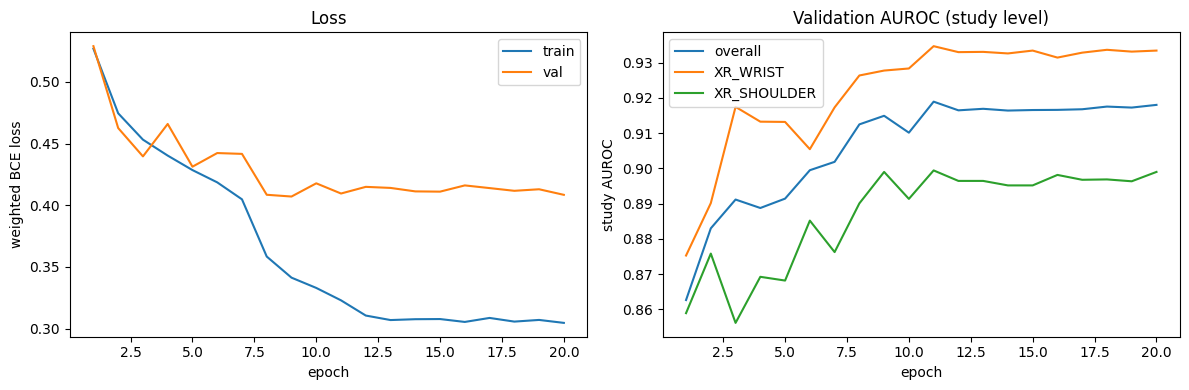

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = list(range(1, len(history['train_loss']) + 1))
axes[0].plot(epochs_range, history['train_loss'], label='train')
axes[0].plot(epochs_range, history['val_loss'],   label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('weighted BCE loss')
axes[0].set_title('Loss')
axes[0].legend()

overall_auroc  = [m.get('overall', {}).get('AUROC', float('nan'))
                  for m in history['study_metrics']]
wrist_auroc    = [m.get('XR_WRIST', {}).get('AUROC', float('nan'))
                  for m in history['study_metrics']]
shoulder_auroc = [m.get('XR_SHOULDER', {}).get('AUROC', float('nan'))
                  for m in history['study_metrics']]
axes[1].plot(epochs_range, overall_auroc,  label='overall')
axes[1].plot(epochs_range, wrist_auroc,    label='XR_WRIST')
axes[1].plot(epochs_range, shoulder_auroc, label='XR_SHOULDER')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('study AUROC')
axes[1].set_title('Validation AUROC (study level)')
axes[1].legend()

plt.tight_layout()
plt.show()
